In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
class_names = ['armyworm','beetle','cicadellidae','cricket','grasshopper','limacodidae','lycorma_delicatula','mosquito','weevil']

In [ ]:
cd drive/MyDrive

[Errno 2] No such file or directory: 'drive/MyDrive'
/content/drive/MyDrive


In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.models import Model
import tensorflow as tf
import numpy as np
import os
import glob
import cv2

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder


In [ ]:
image_size = 224
data_path = 'data'

In [ ]:
def build_model(image_size=224, n_class=3):
    # Load VGG16 with pre-trained weights
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(image_size, image_size, 3))

    # Freeze early layers
    for layer in base_model.layers[:15]:
        layer.trainable = False

    # Build model
    input = Input(shape=(image_size, image_size, 3), name='image_input')
    x = base_model(input)
    x = GlobalAveragePooling2D()(x)
    x = Dense(4096, activation='relu', name='fc1')(x)
    x = Dropout(0.5)(x)
    x = Dense(4096, activation='relu', name='fc2')(x)
    x = Dropout(0.5)(x)
    output = Dense(n_class, activation='softmax', name='predictions')(x)

    # Compile model
    model = Model(inputs=input, outputs=output)
    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        metrics=['accuracy']
    )

    return model


In [ ]:
def load_data(data_path, class_names, image_size):
    data = []
    label = []
    for i_class in class_names:
        read_path = os.path.join(data_path, i_class,"*")
        print(read_path)
        for file in glob.glob(read_path):
            # Read
            print(file)
            image = cv2.imread(file)
            # Resize
            image = cv2.resize(image, dsize=(image_size, image_size))
            # Add to data
            data.append(image)
            label.append(i_class)

    # Encode labels from text to onehot
    label_encoder = LabelEncoder()
    integer_encoded = label_encoder.fit_transform(label)
    onehot_encoder = OneHotEncoder(sparse_output=False)
    integer_encoded = integer_encoded.reshape(len(integer_encoded), 1)
    onehot_encoded = onehot_encoder.fit_transform(integer_encoded)

    # Change to numpy array
    label = onehot_encoded
    data = np.array(data)
    return data, label, label_encoder



In [ ]:
my_model = build_model(image_size,len(class_names))

In [ ]:
from sklearn.model_selection import train_test_split
# Make model
#model = build_model(image_size, len(class_names))

# Load data train from folder
X, y, le = load_data(os.path.join(data_path), class_names, image_size)

# Load data test from folder
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=100)
print(X_train.shape)
print(y_train.shape)

import pickle
file = open('le.pkl', 'wb')
pickle.dump(le, file)
file.close()


Streaming output truncated to the last 5000 lines.
data/armyworm/28995.jpg
data/armyworm/17071.jpg
data/armyworm/28959.jpg
data/armyworm/29086.jpg
data/armyworm/16587.jpg
data/armyworm/16766.jpg
data/armyworm/jpg_39.jpg
data/armyworm/16817.jpg
data/armyworm/jpg_45.jpg
data/armyworm/jpg_79.jpg
data/armyworm/16553.jpg
data/armyworm/16882.jpg
data/armyworm/16658.jpg
data/armyworm/29084.jpg
data/armyworm/jpg_50.jpg
data/armyworm/16626.jpg
data/armyworm/16934.jpg
data/armyworm/16958.jpg
data/armyworm/29091.jpg
data/armyworm/16839.jpg
data/armyworm/16810.jpg
data/armyworm/16571.jpg
data/armyworm/16594.jpg
data/armyworm/16733.jpg
data/armyworm/16832.jpg
data/armyworm/16823.jpg
data/armyworm/16771.jpg
data/armyworm/16762.jpg
data/armyworm/16703.jpg
data/armyworm/29113.jpg
data/armyworm/29195.jpg
data/armyworm/16561.jpg
data/armyworm/29026.jpg
data/armyworm/jpg_77.jpg
data/armyworm/28941.jpg
data/armyworm/16520.jpg
data/armyworm/jpg_34.jpg
data/armyworm/16640.jpg
data/armyworm/16918.jpg
data/ar

In [ ]:
my_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc1 (Dense)                          │ (None, 4096)                │       2,101,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc2 (Dense)                          │ (None, 4096)                │      16,781,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ predictions (Dense)                  │ (None, 9)                   │          36,873 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,634,121 (128.30 MB)

 Trainable params: 25,998,857 (99.18 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint

In [ ]:
aug = ImageDataGenerator(
	    rotation_range=40,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      horizontal_flip=True,
      fill_mode='nearest')

In [ ]:
#filepath="weights-{epoch:02d}-{val_accuracy:.2f}.hdf5"
filepath="VGG16-f-w-max.keras"
checkpoint = ModelCheckpoint(filepath, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
callbacks_list = [checkpoint]

In [ ]:
import time
start = time.time()
hist = my_model.fit(aug.flow(X_train, y_train, batch_size = 64), callbacks=callbacks_list, epochs=30, validation_data=aug.flow(X_test, y_test, batch_size = 64), verbose=1)
end = time.time()
print("Training time : ", end - start)

Epoch 1/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 800ms/step - accuracy: 0.8360 - loss: 0.5253
Epoch 1: val_accuracy improved from 0.76987 to 0.84011, saving model to VGG16-f-w-max.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8362 - loss: 0.5249 - val_accuracy: 0.8401 - val_loss: 0.5801
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 845ms/step - accuracy: 0.8707 - loss: 0.4089
Epoch 2: val_accuracy improved from 0.84011 to 0.84566, saving model to VGG16-f-w-max.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.8707 - loss: 0.4088 - val_accuracy: 0.8457 - val_loss: 0.5821
Epoch 3/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 838ms/step - accuracy: 0.9034 - loss: 0.3218
Epoch 3: val_accuracy improved from 0.84566 to 0.85213, saving model to VGG16-f-w-max.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.9033 - loss: 0.3219 - val_accuracy: 0.8521 - val_loss: 0.4905
Epoch 4/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 811ms/step - accuracy: 0.9116 - loss: 0.2806
Epoch 4: val_accuracy improved from

In [ ]:
my_model.save("VGG16-f-w-last.hdf5")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_model_history(model_history, acc='accuracy', val_acc='val_accuracy'):
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))

    # Plot accuracy
    epochs = range(1, len(model_history.history[acc]) + 1)
    axs[0].plot(epochs, model_history.history[acc], label='Train Accuracy')
    axs[0].plot(epochs, model_history.history[val_acc], label='Validation Accuracy')
    axs[0].set_title('Model Accuracy')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_xlabel('Epoch')
    axs[0].set_xticks(np.arange(1, len(epochs) + 1, step=max(1, len(epochs) // 10)))
    axs[0].legend(loc='best')

    # Plot loss
    axs[1].plot(epochs, model_history.history['loss'], label='Train Loss')
    axs[1].plot(epochs, model_history.history['val_loss'], label='Validation Loss')
    axs[1].set_title('Model Loss')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].set_xticks(np.arange(1, len(epochs) + 1, step=max(1, len(epochs) // 10)))
    axs[1].legend(loc='best')

    plt.tight_layout()
    plt.show()


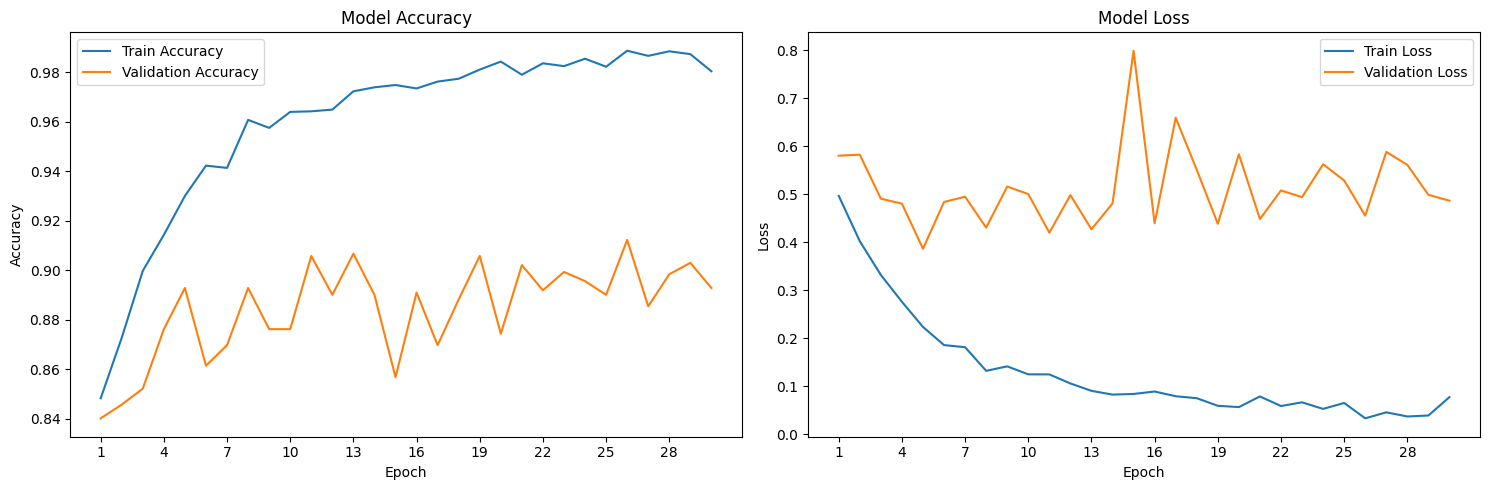

In [ ]:
plot_model_history(hist)